#### Question 4

In [1]:
# general libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, solve
from sympy import diff, simplify

Define f(x) and the constraint function

In [2]:
def objFunc(x):
    return x**2 + 1
def cons1(x):
    return x**2 - 6 * x + 7

(a) Write the Lagrangian, and plot it for different values of λ ≥ 0

In [3]:
def lagrangeF(x, lam):
    return objFunc(x) + lam * (cons1(x))

In [4]:
# define the feasible space of f(x)
x = symbols('x')
solve(x**2 - 6 * x + 7 <= 0)

(x <= sqrt(2) + 3) & (3 - sqrt(2) <= x)

Our feasible space is defined as $3 - \sqrt(2) \leq x \leq 3 + \sqrt(2)$

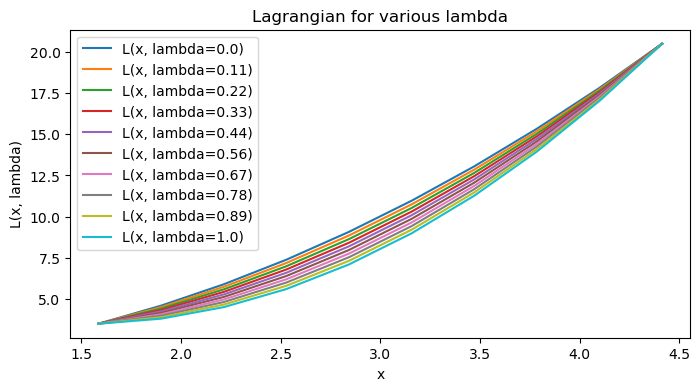

In [5]:
# plot the Lagrangian over our feasible space
x = np.linspace(3-np.sqrt(2), 3+np.sqrt(2), 10)
lam = np.linspace(0, 1, 10)

lagrangeFuncSets = {}
for i, lamd in enumerate(lam):
    lagrangeFuncSets[str(lamd.round(2))] = np.array([lagrangeF(u, lamd) for u in x])

fig, ax = plt.subplots(figsize=(8,4))
for k, v in lagrangeFuncSets.items():
    ax.plot(x, v, label=f"L(x, lambda={k})")
plt.legend(loc='best')
plt.title('Lagrangian for various lambda')
plt.xlabel('x'); plt.ylabel('L(x, lambda)');

plt.show()

From the Lagrangian, we obtain the primal variable 'x' in terms of lambda, which we will use to derive the dual function (i.e., alternate Lagrangian as a g(lambda).

In [6]:
# define Lagrangian function variables
x, lam = symbols('x lam', real=True)

# define objective function and constraint
f = x**2 + 1

g_cons = x**2 - 6 * x + 7

# define the Lagrangian
L = f + lam * g_cons

# compute the gradients (first derivatives) of the Lagrangian function to minimize L with respect to x (primal variable) ==> used to obtain the dual function, g(lambda)
grad_L_x = diff(L, x)

# evaluate the gradient of L at x, which is a function of lambda
x_sol = solve(grad_L_x, x)[0]
print(f"Primal variables as functions of lambda: {x_sol}")

Primal variables as functions of lambda: 3*lam/(lam + 1)


(b) Write the dual function and then write the dual problem. Plot the dual function.

In [7]:
# obtain the dual function by substituting x in terms of lambda back into L ==> g(lambda)
g_lam = simplify(L.subs(x, x_sol))
print(f"Dual Function g(lambda): {g_lam}")

Dual Function g(lambda): (-2*lam**2 + 8*lam + 1)/(lam + 1)


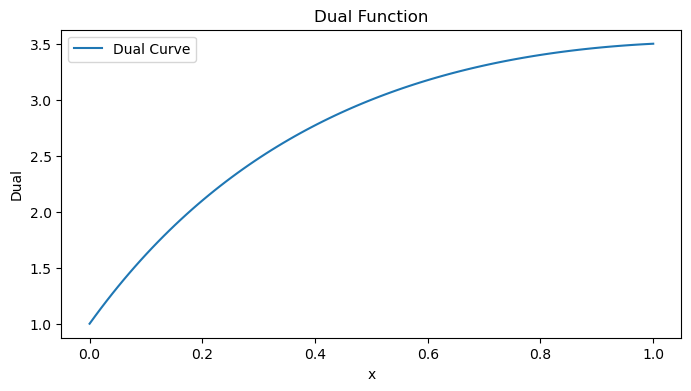

In [8]:
# plot the dual function
def dualF(lam): # lam is the eigenvalue
    return (-2*lam**2 + 8*lam + 1)/(lam + 1)

u = np.linspace(0, 1, 100)
dual_val = np.zeros(len(u))

for i in range(len(u)):
    dual_val[i] = dualF(u[i])

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(u, dual_val, label=f"Dual Curve")
plt.legend(loc='best')
plt.title('Dual Function')
plt.xlabel('x'); plt.ylabel('Dual');

plt.show()

The dual function is typically expressed as max $\Theta(\lambda)$ such that $\lambda \geq 0$. The dual function is concave.

Solve the dual problem.

In [9]:
# solve the dual problem (i.e., maximize) by computing the gradient with respect to lambda ==> optimal lambda
dg_lam = diff(g_lam, lam)
lam_opt = solve(dg_lam, lam)[0]

Solve the primal problem.

In [10]:
# solve the primal problem by substituting optimal lambda (lam_sol) from the dual problem into the expression for x (primal variable)
x_opt = x_sol.subs(lam, lam_opt)

print(f"Optimal Dual Variable (lambda*): {lam_opt}")
print(f"Optimal Primal Variable (x*): {x_opt}")

Optimal Dual Variable (lambda*): -1 + 3*sqrt(2)/2
Optimal Primal Variable (x*): sqrt(2)*(-1 + 3*sqrt(2)/2)


Compute the duality gap: The duality gap is the difference between the primal and dual objective function values corresponding to the optimal solution.

In [11]:
x_opt = np.sqrt(2)*(-1 + 3*np.sqrt(2)/2)
lambda_opt = -1 + 3*np.sqrt(2)/2
print(f"x_opt = {x_opt}, lambda_opt = {lambda_opt}")

x_opt = 1.5857864376269055, lambda_opt = 1.1213203435596428


In [12]:
objFunc(x_opt) - dualF(lambda_opt) 

np.float64(1.3322676295501878e-15)

Based on an infinitesimally small duality gap, given our particular function and constraint, minimizing the function with respect to the constraint is equivalent to maximizing the related curve with respect to maximum eigenvalue.